In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
csv_path = 'mnist_dataset.csv'
assert os.path.exists(csv_path), 'Dataset file is missing'
df = pd.read_csv(csv_path)
x_data = df.values.astype('float32') / 255.0
from tensorflow.keras.datasets import mnist
(x_mnist, y_mnist), (_, _) = mnist.load_data()
y_data = y_mnist[:x_data.shape[0]]
x_data = x_data.reshape((-1, 28*28))
print('loaded', x_data.shape, y_data.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
loaded (42000, 784) (42000,)


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, stratify=y_data, random_state=42)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
print('split', x_train.shape, x_test.shape)

split (33600, 784) (8400, 784)


In [10]:
def build_mlp(hidden_layers, dropout_rate=0.3, batch_norm=False):
    model = Sequential()
    model.add(tf.keras.Input(shape=(784,)))
    model.add(Dense(hidden_layers[0], activation='relu'))
    if batch_norm:
        model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    for size in hidden_layers[1:]:
        model.add(Dense(size, activation='relu'))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [12]:
def train_and_eval(model, name, epochs=20, batch_size=128):
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    history = model.fit(x_train, y_train_cat, validation_split=0.2, epochs=epochs, batch_size=batch_size, callbacks=[es, rl], verbose=2)
    score = model.evaluate(x_test, y_test_cat, verbose=0)
    y_pred = np.argmax(model.predict(x_test), axis=1)
    metrics = {'name': name, 'loss': score[0], 'accuracy': score[1], 'precision': precision_score(y_test, y_pred, average='macro', zero_division=0), 'recall': recall_score(y_test, y_pred, average='macro', zero_division=0), 'f1': f1_score(y_test, y_pred, average='macro', zero_division=0)}
    print(name, 'test acc', metrics['accuracy'], 'f1', metrics['f1'])
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(name + ' loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(name + ' accuracy')
    plt.legend()
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=False, cmap='viridis')
    plt.title(name + ' confusion matrix')
    plt.xlabel('pred')
    plt.ylabel('true')
    plt.show()
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    return metrics

Epoch 1/20
210/210 - 5s - 22ms/step - accuracy: 0.1044 - loss: 2.3112 - val_accuracy: 0.1027 - val_loss: 2.3025 - learning_rate: 0.0010
Epoch 2/20
210/210 - 2s - 10ms/step - accuracy: 0.1093 - loss: 2.3029 - val_accuracy: 0.1022 - val_loss: 2.3022 - learning_rate: 0.0010
Epoch 3/20
210/210 - 1s - 3ms/step - accuracy: 0.1130 - loss: 2.3015 - val_accuracy: 0.1137 - val_loss: 2.3022 - learning_rate: 0.0010
Epoch 4/20
210/210 - 1s - 3ms/step - accuracy: 0.1128 - loss: 2.3007 - val_accuracy: 0.1132 - val_loss: 2.3020 - learning_rate: 0.0010
Epoch 5/20
210/210 - 1s - 3ms/step - accuracy: 0.1177 - loss: 2.2996 - val_accuracy: 0.1138 - val_loss: 2.3029 - learning_rate: 0.0010
Epoch 6/20
210/210 - 1s - 3ms/step - accuracy: 0.1159 - loss: 2.2986 - val_accuracy: 0.1110 - val_loss: 2.3027 - learning_rate: 0.0010
Epoch 7/20
210/210 - 1s - 3ms/step - accuracy: 0.1159 - loss: 2.2978 - val_accuracy: 0.1083 - val_loss: 2.3049 - learning_rate: 0.0010
Epoch 8/20
210/210 - 1s - 3ms/step - accuracy: 0.1209

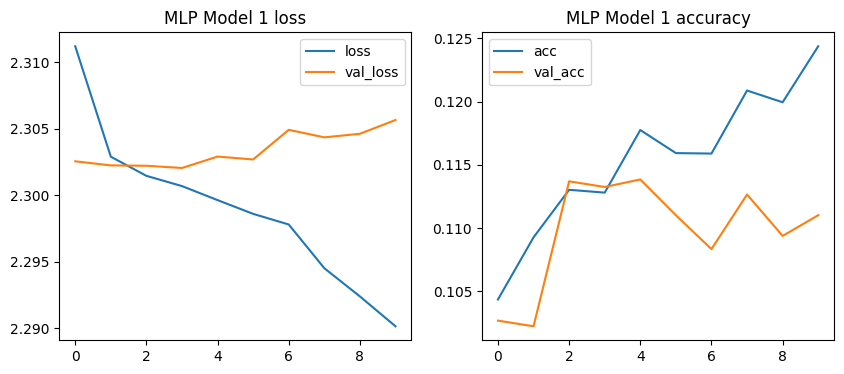

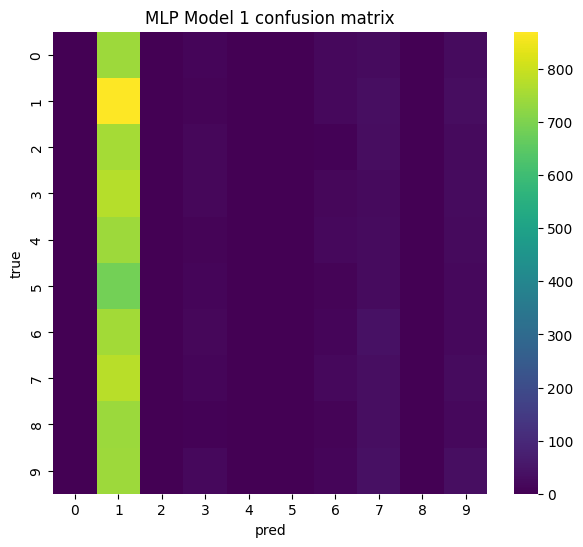

              precision    recall  f1-score   support

           0     0.2500    0.0012    0.0024       829
           1     0.1149    0.9062    0.2039       960
           2     0.0769    0.0012    0.0024       829
           3     0.1270    0.0188    0.0327       853
           4     0.0000    0.0000    0.0000       820
           5     0.0000    0.0000    0.0000       757
           6     0.0827    0.0132    0.0227       836
           7     0.1104    0.0381    0.0567       866
           8     0.0000    0.0000    0.0000       808
           9     0.1339    0.0380    0.0592       842

    accuracy                         0.1148      8400
   macro avg     0.0896    0.1017    0.0380      8400
weighted avg     0.0913    0.1148    0.0411      8400



In [13]:
mlp_model_1 = build_mlp(hidden_layers=[128, 64], dropout_rate=0.3, batch_norm=False)
metrics_1 = train_and_eval(mlp_model_1, 'MLP Model 1')